# GVH_Rossler_Pipeline_0.1

## Titre

**Pipeline GVH appliqué au système de Rössler**

## Version

0.1

## Objectif général

Ce notebook applique les observables GVH au système dynamique de Rössler afin d’étudier sa géométrie trajectorielle, sa dispersion multi-échelle et ses signatures angulaires.

Le pipeline suit la même structure méthodologique que `GVH_Lorenz_Pipeline_0.1`, afin de permettre une comparaison directe entre systèmes chaotiques.

## Statut

Version descriptive, reproductible, indépendante de toute interprétation physique liée au Volume Partagé.

## Auteur

Charlemagne O. Laurince

## 2. Objectif du pipeline

L’objectif de ce notebook est d’appliquer le cadre descriptif GVH à une trajectoire générée par le système dynamique de Rössler.

Le pipeline vise à :

- générer numériquement une trajectoire du système de Rössler ;
- supprimer le régime transitoire afin de concentrer l’analyse sur la dynamique asymptotique ;
- construire une représentation trajectorielle adaptée au calcul des observables GVH ;
- calculer un ensemble cohérent d’observables géométriques et multi-échelles :
  - \(D_T^{\mathrm{mean}}\),
  - \(S_T\),
  - \(S_T^{\mathrm{norm}}\),
  - \(D_c\),
  - \(R_{\mathrm{super}}\),
  - \(A_H\),
  - \(B_H\),
  - \(\theta_{\mathrm{mean}}\),
  - \(\theta_{\max}\),
  - \(R_{180}\) ;
- produire des figures diagnostiques permettant d’examiner la structure géométrique de la trajectoire ;
- exporter les observables et la trajectoire analysée sous forme de fichiers CSV reproductibles ;
- préparer une comparaison méthodologiquement homogène avec les pipelines GVH appliqués aux systèmes de Lorenz et de Duffing.

Cette version 0.1 est volontairement descriptive. Elle ne cherche pas à attribuer une interprétation physique fondamentale aux observables calculées.

L’objectif principal est d’évaluer si une même chaîne de calcul GVH peut être appliquée de manière cohérente à différents systèmes dynamiques non linéaires, tout en conservant des signatures géométriques propres à chaque dynamique.

 3. Imports Python.

In [ ]:
# ============================================================
# 3. Imports Python
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# Reproductibilité
SEED = 42
np.random.seed(SEED)

# Affichage numérique
np.set_printoptions(
    precision=6,
    suppress=True
)

# Affichage pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 6)

print("Imports chargés avec succès.")
print(f"Seed de reproductibilité : {SEED}")

Imports chargés avec succès.
Seed de reproductibilité : 42


cellule 4 — Paramètres du système de Rössler.

In [ ]:
# ============================================================
# 4. Paramètres du système de Rössler
# ============================================================

# Paramètres classiques du régime chaotique de Rössler
a = 0.2
b = 0.2
c = 5.7

# Conditions initiales
y0 = np.array([1.0, 0.0, 0.0])

# Paramètres temporels
t_min = 0.0
t_max = 500.0
n_points = 50000

t_eval = np.linspace(t_min, t_max, n_points)

print("Paramètres du système de Rössler :")
print(f"a = {a}")
print(f"b = {b}")
print(f"c = {c}")
print(f"Conditions initiales : {y0}")
print(f"Intervalle temporel : [{t_min}, {t_max}]")
print(f"Nombre de points : {n_points}")

Paramètres du système de Rössler :
a = 0.2
b = 0.2
c = 5.7
Conditions initiales : [1. 0. 0.]
Intervalle temporel : [0.0, 500.0]
Nombre de points : 50000


5. Définition et intégration numérique du système de Rössler

In [ ]:
# ============================================================
# 5. Définition et intégration numérique du système de Rössler
# ============================================================

def rossler_system(t, state, a, b, c):
    """
    Système de Rössler :
        dx/dt = -y - z
        dy/dt = x + a y
        dz/dt = b + z(x - c)
    """
    x, y, z = state

    dxdt = -y - z
    dydt = x + a * y
    dzdt = b + z * (x - c)

    return [dxdt, dydt, dzdt]


solution = solve_ivp(
    fun=lambda t, state: rossler_system(t, state, a, b, c),
    t_span=(t_min, t_max),
    y0=y0,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-9,
    atol=1e-12
)

if not solution.success:
    raise RuntimeError("L'intégration numérique du système de Rössler a échoué.")

t = solution.t
x, y, z = solution.y

trajectory = np.column_stack([x, y, z])

print("Intégration numérique terminée avec succès.")
print(f"Forme de la trajectoire : {trajectory.shape}")
print(f"Temps initial : {t[0]:.3f}")
print(f"Temps final : {t[-1]:.3f}")

Intégration numérique terminée avec succès.
Forme de la trajectoire : (50000, 3)
Temps initial : 0.000
Temps final : 500.000


cellule 6 — Visualisation rapide de la trajectoire brute.

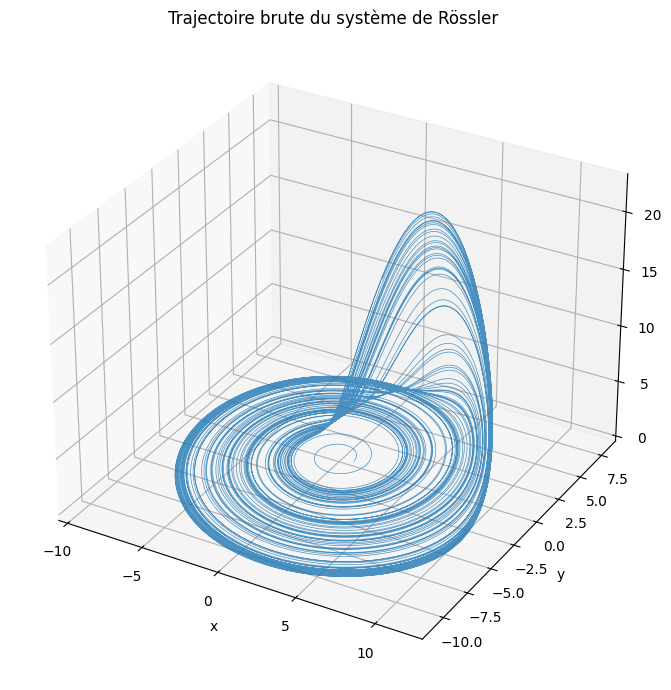

In [ ]:
# ============================================================
# 6. Visualisation rapide de la trajectoire brute
# ============================================================

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    x,
    y,
    z,
    linewidth=0.5,
    alpha=0.8
)

ax.set_title("Trajectoire brute du système de Rössler")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.tight_layout()
plt.show()

cellule 7 — Suppression du régime transitoire.

In [ ]:
# ============================================================
# 7. Suppression du régime transitoire
# ============================================================

# Fraction initiale retirée pour supprimer le transitoire
transient_fraction = 0.20
transient_index = int(transient_fraction * len(t))

t_gvh = t[transient_index:]
trajectory_gvh = trajectory[transient_index:]

x_gvh = trajectory_gvh[:, 0]
y_gvh = trajectory_gvh[:, 1]
z_gvh = trajectory_gvh[:, 2]

print("Suppression du régime transitoire terminée.")
print(f"Fraction retirée : {transient_fraction:.0%}")
print(f"Index de coupure : {transient_index}")
print(f"Nombre de points conservés : {len(t_gvh)}")
print(f"Forme de la trajectoire GVH : {trajectory_gvh.shape}")

Suppression du régime transitoire terminée.
Fraction retirée : 20%
Index de coupure : 10000
Nombre de points conservés : 40000
Forme de la trajectoire GVH : (40000, 3)


cellule 8 — Visualisation de la trajectoire après suppression du transitoire.

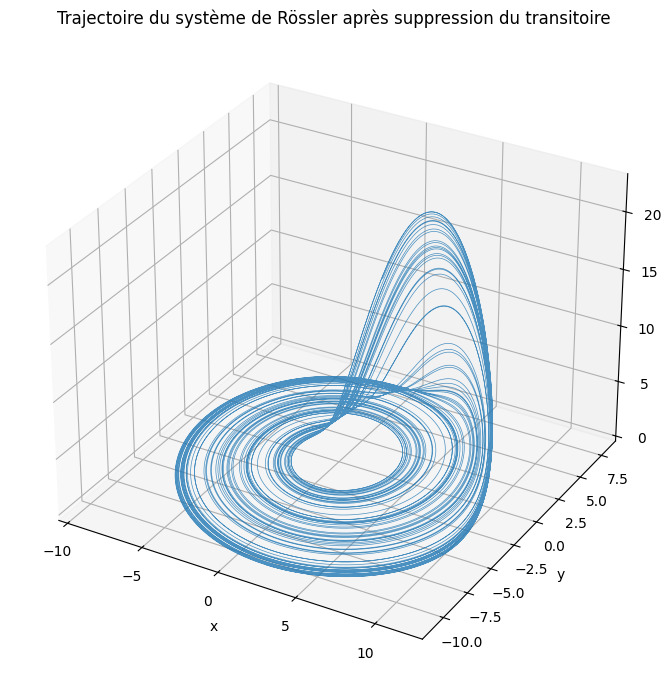

In [ ]:
# ============================================================
# 8. Visualisation de la trajectoire après suppression
#    du régime transitoire
# ============================================================

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    x_gvh,
    y_gvh,
    z_gvh,
    linewidth=0.5,
    alpha=0.8
)

ax.set_title(
    "Trajectoire du système de Rössler après suppression du transitoire"
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.tight_layout()
plt.show()

cellule 9 — Construction des incréments trajectoriels GVH.

In [ ]:
# ============================================================
# 9. Construction des incréments trajectoriels GVH
# ============================================================

# Incréments trajectoriels entre deux points successifs
increments = np.diff(trajectory_gvh, axis=0)

# Norme locale des incréments : observable de distance locale
D_T = np.linalg.norm(increments, axis=1)

# Temps associé aux incréments
t_D = t_gvh[1:]

print("Construction des incréments GVH terminée.")
print(f"Forme des incréments : {increments.shape}")
print(f"Nombre de valeurs D_T : {len(D_T)}")
print(f"D_T min  : {D_T.min():.6e}")
print(f"D_T max  : {D_T.max():.6e}")
print(f"D_T mean : {D_T.mean():.6e}")
print(f"D_T std  : {D_T.std():.6e}")

Construction des incréments GVH terminée.
Forme des incréments : (39999, 3)
Nombre de valeurs D_T : 39999
D_T min  : 2.501925e-02
D_T max  : 6.403761e-01
D_T mean : 8.698191e-02
D_T std  : 7.991429e-02


cellule 10 — Visualisation de D_T(t).

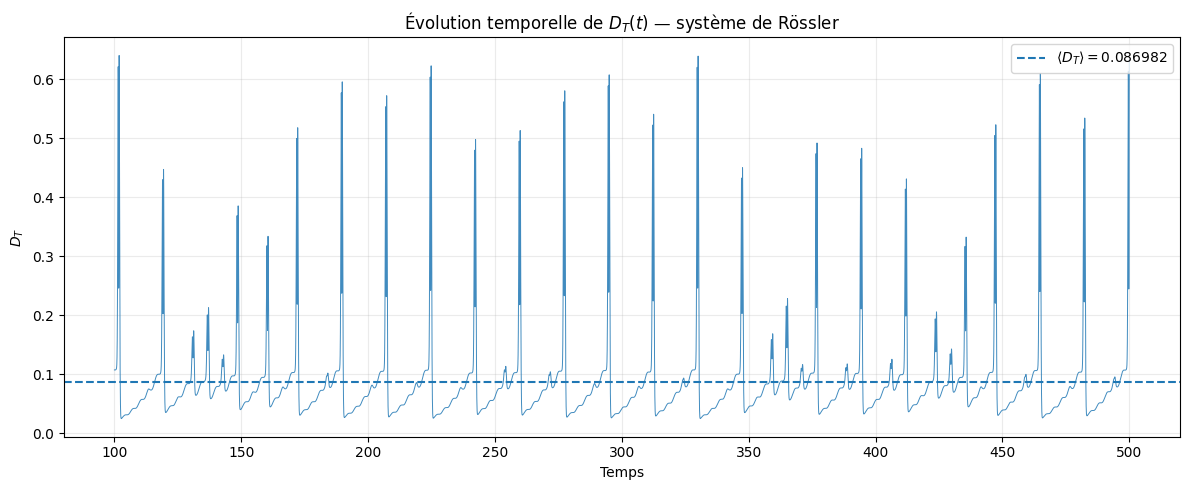

D_T_mean = 0.086982


In [ ]:
# ============================================================
# 10. Visualisation de D_T(t)
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    t_D,
    D_T,
    linewidth=0.7,
    alpha=0.85
)

# Moyenne globale de D_T
D_T_mean = np.mean(D_T)

plt.axhline(
    D_T_mean,
    linestyle="--",
    linewidth=1.5,
    label=fr"$\langle D_T \rangle = {D_T_mean:.6f}$"
)

plt.title(r"Évolution temporelle de $D_T(t)$ — système de Rössler")
plt.xlabel("Temps")
plt.ylabel(r"$D_T$")

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"D_T_mean = {D_T_mean:.6f}")

cellule 11 — Calcul de S_T et S_T^{\rm norm}.

In [ ]:
# ============================================================
# 11. Calcul de S_T et S_T_norm
# ============================================================

# Dispersion globale de D_T
S_T = np.std(D_T)

# Dispersion normalisée
S_T_norm = S_T / D_T_mean

print("Calcul de S_T et S_T_norm terminé.")
print(f"S_T      = {S_T:.6e}")
print(f"S_T_norm = {S_T_norm:.6e}")

Calcul de S_T et S_T_norm terminé.
S_T      = 7.991429e-02
S_T_norm = 9.187461e-01


cellule 12 — Définition de D_c et calcul de R_{\rm super}.

In [ ]:
# ============================================================
# 12. Définition de D_c et calcul de R_super
# ============================================================

# Seuil critique GVH
# Choix descriptif 0.1 : moyenne + un écart-type
D_c = D_T_mean + S_T

# Fraction des incréments au-dessus du seuil critique
R_super = np.mean(D_T > D_c)

print("Calcul de D_c et R_super terminé.")
print(f"D_c      = {D_c:.6e}")
print(f"R_super  = {R_super:.6e}")
print(f"R_super (%) = {100 * R_super:.3f}%")

Calcul de D_c et R_super terminé.
D_c      = 1.668962e-01
R_super  = 6.480162e-02
R_super (%) = 6.480%


cellule : 13. Calcul de A_H et B_H

In [ ]:
# ============================================================
# 13. Calcul de A_H et B_H
# ============================================================

# Modèle descriptif GVH :
# R_super(D_c) = A_H * exp(-B_H * D_c)

def exponential_model(D, A, B):
    return A * np.exp(-B * D)


# Construction d'une gamme de seuils D_c
D_c_values = np.linspace(
    np.percentile(D_T, 5),
    np.percentile(D_T, 95),
    100
)

# Calcul de R_super pour chaque seuil
R_super_values = np.array([
    np.mean(D_T > Dc) for Dc in D_c_values
])

# Ajustement exponentiel
popt, pcov = curve_fit(
    exponential_model,
    D_c_values,
    R_super_values,
    p0=(1.0, 1.0),
    maxfev=10000
)

A_H, B_H = popt

# Courbe ajustée
R_fit = exponential_model(D_c_values, A_H, B_H)

print("Calcul de A_H et B_H terminé.")
print(f"A_H = {A_H:.6e}")
print(f"B_H = {B_H:.6e}")

Calcul de A_H et B_H terminé.
A_H = 2.157931e+00
B_H = 2.247467e+01


cellule : 14. Visualisation de l’ajustement exponentiel R_{\rm super}(D_c).

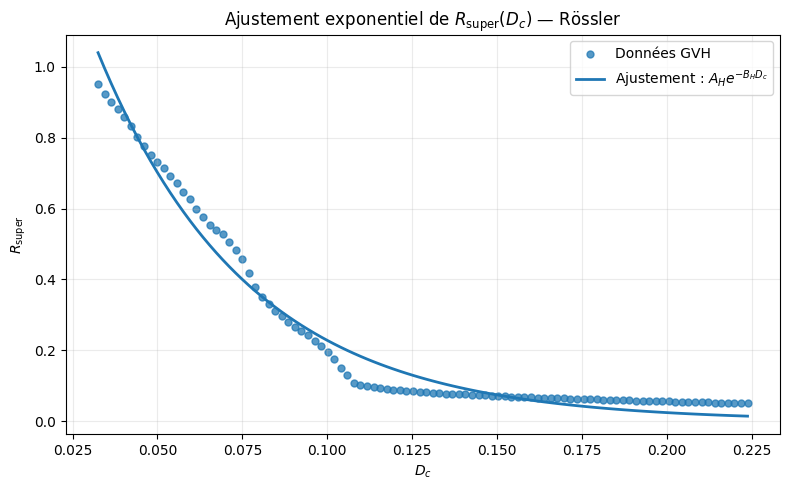

A_H = 2.157931
B_H = 22.474675


In [ ]:
# ============================================================
# 14. Visualisation de l'ajustement exponentiel R_super(D_c)
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    D_c_values,
    R_super_values,
    s=25,
    alpha=0.75,
    label="Données GVH"
)

plt.plot(
    D_c_values,
    R_fit,
    linewidth=2,
    label=fr"Ajustement : $A_H e^{{-B_H D_c}}$"
)

plt.title(r"Ajustement exponentiel de $R_{\rm super}(D_c)$ — Rössler")
plt.xlabel(r"$D_c$")
plt.ylabel(r"$R_{\rm super}$")

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"A_H = {A_H:.6f}")
print(f"B_H = {B_H:.6f}")

cellule 15. Calcul des angles trajectoriels \theta.

In [ ]:
# ============================================================
# 15. Calcul des angles trajectoriels theta
# ============================================================

# Vecteurs incrémentaux successifs
v1 = increments[:-1]
v2 = increments[1:]

# Produits scalaires
dot_products = np.sum(v1 * v2, axis=1)

# Normes des vecteurs
norm_v1 = np.linalg.norm(v1, axis=1)
norm_v2 = np.linalg.norm(v2, axis=1)

# Sécurité numérique
cos_theta = dot_products / (norm_v1 * norm_v2)
cos_theta = np.clip(cos_theta, -1.0, 1.0)

# Angles en radians puis degrés
theta_rad = np.arccos(cos_theta)
theta_deg = np.degrees(theta_rad)

theta_mean = np.mean(theta_deg)
theta_max = np.max(theta_deg)

print("Calcul des angles trajectoriels terminé.")
print(f"Nombre d'angles theta : {len(theta_deg)}")
print(f"theta_mean = {theta_mean:.6f} degrés")
print(f"theta_max  = {theta_max:.6f} degrés")

Calcul des angles trajectoriels terminé.
Nombre d'angles theta : 39998
theta_mean = 0.721336 degrés
theta_max  = 12.562516 degrés


cellule 16. Calcul de R_{180}.

In [ ]:
# ============================================================
# 16. Calcul de R_180
# ============================================================

# Seuil d'opposition angulaire
theta_180_threshold = 170.0

# Fraction des angles proches de 180 degrés
R_180 = np.mean(theta_deg >= theta_180_threshold)

print("Calcul de R_180 terminé.")
print(f"Seuil angulaire : {theta_180_threshold:.1f} degrés")
print(f"R_180 = {R_180:.6e}")
print(f"R_180 (%) = {100 * R_180:.6f}%")

Calcul de R_180 terminé.
Seuil angulaire : 170.0 degrés
R_180 = 0.000000e+00
R_180 (%) = 0.000000%


cellule 17. Tableau récapitulatif des observables GVH.

In [ ]:
# ============================================================
# 17. Tableau récapitulatif des observables GVH
# ============================================================

observables_gvh = pd.DataFrame({
    "Observable": [
        "D_T_mean",
        "S_T",
        "S_T_norm",
        "D_c",
        "R_super",
        "A_H",
        "B_H",
        "theta_mean",
        "theta_max",
        "R_180"
    ],
    "Valeur": [
        D_T_mean,
        S_T,
        S_T_norm,
        D_c,
        R_super,
        A_H,
        B_H,
        theta_mean,
        theta_max,
        R_180
    ]
})

observables_gvh

,Observable,Valeur
0,D_T_mean,0.086982
1,S_T,0.079914
2,S_T_norm,0.918746
3,D_c,0.166896
4,R_super,0.064802
5,A_H,2.157931
6,B_H,22.474675
7,theta_mean,0.721336
8,theta_max,12.562516
9,R_180,0.000000


In [ ]:
# ============================================================
# 17. Tableau récapitulatif des observables GVH
# ============================================================

observables_gvh = pd.DataFrame({
    "Observable": [
        "D_T_mean",
        "S_T",
        "S_T_norm",
        "D_c",
        "R_super",
        "A_H",
        "B_H",
        "theta_mean",
        "theta_max",
        "R_180"
    ],
    "Valeur": [
        D_T_mean,
        S_T,
        S_T_norm,
        D_c,
        R_super,
        A_H,
        B_H,
        theta_mean,
        theta_max,
        R_180
    ]
})

display(observables_gvh)

,Observable,Valeur
0,D_T_mean,0.086982
1,S_T,0.079914
2,S_T_norm,0.918746
3,D_c,0.166896
4,R_super,0.064802
5,A_H,2.157931
6,B_H,22.474675
7,theta_mean,0.721336
8,theta_max,12.562516
9,R_180,0.000000


cellule : 18. Histogramme de D_T.

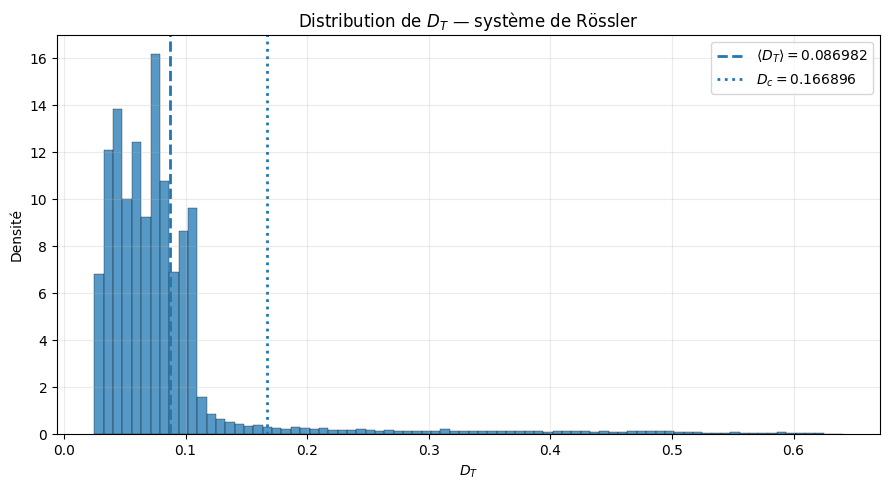

In [ ]:
# ============================================================
# 18. Histogramme de D_T
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    D_T,
    bins=80,
    density=True,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.3
)

# Moyenne de D_T
plt.axvline(
    D_T_mean,
    linestyle="--",
    linewidth=2,
    label=fr"$\langle D_T \rangle = {D_T_mean:.6f}$"
)

# Seuil critique D_c
plt.axvline(
    D_c,
    linestyle=":",
    linewidth=2,
    label=fr"$D_c = {D_c:.6f}$"
)

plt.title(r"Distribution de $D_T$ — système de Rössler")
plt.xlabel(r"$D_T$")
plt.ylabel("Densité")

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

cellule 19. Histogramme des angles trajectoriels \theta.

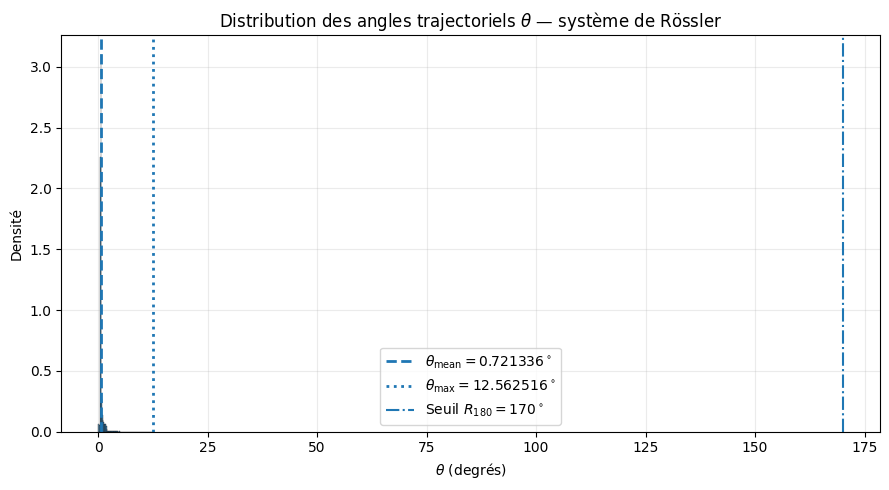

In [ ]:
# ============================================================
# 19. Histogramme des angles trajectoriels theta
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    theta_deg,
    bins=80,
    density=True,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.3
)

# Angle moyen
plt.axvline(
    theta_mean,
    linestyle="--",
    linewidth=2,
    label=fr"$\theta_{{\rm mean}} = {theta_mean:.6f}^\circ$"
)

# Angle maximal
plt.axvline(
    theta_max,
    linestyle=":",
    linewidth=2,
    label=fr"$\theta_{{\max}} = {theta_max:.6f}^\circ$"
)

# Seuil utilisé pour R_180
plt.axvline(
    theta_180_threshold,
    linestyle="-.",
    linewidth=1.5,
    label=fr"Seuil $R_{{180}} = {theta_180_threshold:.0f}^\circ$"
)

plt.title(
    r"Distribution des angles trajectoriels $\theta$ — système de Rössler"
)
plt.xlabel(r"$\theta$ (degrés)")
plt.ylabel("Densité")

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

cellule 20 — Export des observables et de la trajectoire GVH en CSV.

In [ ]:
# ============================================================
# 20. Export des observables et de la trajectoire GVH en CSV
# ============================================================

# Tableau trajectoire post-transitoire
trajectory_gvh_df = pd.DataFrame({
    "t": t_gvh,
    "x": x_gvh,
    "y": y_gvh,
    "z": z_gvh
})

# Tableau des incréments et D_T
increments_gvh_df = pd.DataFrame({
    "t": t_D,
    "dx": increments[:, 0],
    "dy": increments[:, 1],
    "dz": increments[:, 2],
    "D_T": D_T
})

# Export CSV
observables_gvh.to_csv("GVH_Rossler_Observables_0.1.csv", index=False)
trajectory_gvh_df.to_csv("GVH_Rossler_Trajectory_0.1.csv", index=False)
increments_gvh_df.to_csv("GVH_Rossler_Increments_0.1.csv", index=False)

print("Exports terminés :")
print("- GVH_Rossler_Observables_0.1.csv")
print("- GVH_Rossler_Trajectory_0.1.csv")
print("- GVH_Rossler_Increments_0.1.csv")

Exports terminés :
- GVH_Rossler_Observables_0.1.csv
- GVH_Rossler_Trajectory_0.1.csv
- GVH_Rossler_Increments_0.1.csv


## 21. Conclusion descriptive

Le notebook `GVH_Rossler_Pipeline_0.1` applique une chaîne de calcul GVH reproductible à une trajectoire numérique du système de Rössler dans le régime paramétrique :

\[
a = 0.2,
\qquad
b = 0.2,
\qquad
c = 5.7.
\]

Après intégration numérique sur l’intervalle \(t \in [0,500]\), les 20 % premiers points ont été retirés afin de réduire l’influence du régime transitoire. L’analyse GVH a ensuite été réalisée sur une trajectoire post-transitoire de 40 000 points.

Les observables obtenues sont :

\[
D_T^{\mathrm{mean}} = 0.086982,
\]

\[
S_T = 0.079914,
\qquad
S_T^{\mathrm{norm}} = 0.918746,
\]

\[
D_c = 0.166896,
\qquad
R_{\mathrm{super}} = 0.064802,
\]

\[
A_H = 2.157931,
\qquad
B_H = 22.474675,
\]

\[
\theta_{\mathrm{mean}} = 0.721336^\circ,
\qquad
\theta_{\max} = 12.562516^\circ,
\]

\[
R_{180} = 0.
\]

La série temporelle \(D_T(t)\) présente un régime de fond relativement faible accompagné d’excursions locales marquées. La distribution de \(D_T\) est fortement asymétrique, avec une concentration principale aux faibles valeurs et une longue queue vers les grandes amplitudes.

Avec le seuil descriptif

\[
D_c = D_T^{\mathrm{mean}} + S_T,
\]

environ 6.48 % des incréments trajectoriels appartiennent au régime défini ici comme supercritique.

L’ajustement exponentiel

\[
R_{\mathrm{super}}(D_c)
=
A_H \exp(-B_H D_c)
\]

reproduit la tendance décroissante globale de la fraction supercritique. Toutefois, la courbe empirique présente des écarts structurés par rapport à une exponentielle parfaite. Les paramètres \(A_H\) et \(B_H\) doivent donc être considérés, dans cette version 0.1, comme des paramètres descriptifs dépendant du protocole d’ajustement.

L’analyse angulaire montre une forte continuité directionnelle locale entre incréments successifs, avec un angle moyen inférieur à un degré et un angle maximal d’environ \(12.56^\circ\). Aucun événement proche de l’opposition angulaire à \(180^\circ\) n’est observé pour le seuil fixé à \(170^\circ\), ce qui conduit à :

\[
R_{180}=0.
\]

Ces résultats décrivent la trajectoire de Rössler pour les paramètres numériques, le pas d’échantillonnage, la suppression du transitoire et les définitions GVH utilisés dans ce notebook. Ils ne constituent pas, à eux seuls, une preuve d’universalité des observables ni une interprétation physique fondamentale.

Cette version 0.1 établit une base reproductible pour :

- la comparaison avec `GVH_Lorenz_Pipeline_0.1` ;
- la comparaison avec `GVH_Duffing_Pipeline_0.1` ;
- l’étude de la robustesse au pas temporel et au sous-échantillonnage ;
- l’étude de la sensibilité aux conditions initiales ;
- l’étude de la sensibilité aux paramètres \(a\), \(b\) et \(c\) ;
- l’évaluation quantitative de la qualité de l’ajustement exponentiel ;
- les futurs tests Monte Carlo et tests de robustesse au bruit.

Le pipeline reste descriptif et indépendant de toute interprétation théorique liée au modèle du Volume Partagé.

## 22. Environnement numérique et reproductibilité

Ce pipeline a été exécuté dans un environnement Python dépendant notamment de NumPy, SciPy, pandas et matplotlib.

Comme le système de Rössler est chaotique, une reproductibilité bit à bit de la trajectoire n’est pas garantie entre différentes versions de SciPy ou différents solveurs numériques. Les observables GVH doivent donc être interprétées comme des quantités statistiques reproductibles à tolérance près, et non comme des valeurs trajectorielles strictement identiques point par point.

Dans cette exécution, les observables principales restent stables à l’échelle de quelques pour cent, tandis que \(R_{180}=0\) est confirmé.

In [ ]:
import sys
import scipy

print("Environnement numérique :")
print(f"Python  : {sys.version}")
print(f"NumPy   : {np.__version__}")
print(f"SciPy   : {scipy.__version__}")
print(f"pandas  : {pd.__version__}")

Environnement numérique :
Python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy   : 2.0.2
SciPy   : 1.16.3
pandas  : 2.2.2
